# Microglial Engulfment Analysis — WT vs *Opn4* KO

This notebook accompanies the analysis of microglial engulfment of presynaptic input
and regenerates the SuperPlots directly from the pre-computed batch results, so
every figure is reproducible from the raw results CSV.

## Blinding and channel assignment

Analysis was performed by an independent observer with **no knowledge of the
experimental grouping**. To preserve blinding, genotypes were coded as **A** and
**B**, and the imaging channels were kept separate and unlabelled during
processing. The code assignments are:

| Coded label | Actual group |
|---|---|
| A | Wild-type (WT) |
| B | *Opn4* knockout (*Opn4* KO) |

| Channel | Marker | Role |
|---|---|---|
| red | VGluT2 | engulfed presynaptic puncta |
| green | microglia | engulfing volume (reference for engulfment %) |
| blue | CTB | engulfed anterograde tracer |

Engulfment is quantified as the fraction of microglial (green) volume that also
contains VGluT2 (red) or CTB (blue) signal.

## How the data were produced

Values in `data/engulfment_results.csv` are the output of a MATLAB image-analysis
pipeline (`scripts/SimplePunctaAnalysis_v5.m`): per imaging field, each channel is
normalized (percentile contrast stretch), 3-D Gaussian blurred, thresholded at an
adaptive per-channel percentile, and size-filtered on 3-D connected components.
Engulfment, object counts, volumes, and densities are then computed against the
microglial mask. Group-level statistics in the manuscript use a linear mixed model with
animal as a random effect (`Response ~ Group + (1|Animal)`); that analysis is
unchanged here.


In [1]:
# --- Setup -------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import engulfment_plots as ep   # plotting logic lives in this module

CSV_PATH = "data/engulfment_results.csv"   # edit if your CSV is elsewhere
plt.rcParams["figure.dpi"] = 110

df = ep.load_data(CSV_PATH)
print(f"Loaded {len(df)} imaging fields from {df['replicate'].nunique()} animals.")
print("Groups:", {k: v for k, v in ep.GROUP_LABELS.items()})


Loaded 135 imaging fields from 14 animals.
Groups: {'A': 'WT', 'B': 'Opn4 KO'}


## Cohort composition

Animals per genotype, and the number of imaging fields contributing to each.


In [2]:
summary = (df.groupby(["group", "genotype"])
             .agg(n_animals=("replicate", "nunique"),
                  n_fields=("replicate", "size"))
             .reset_index())
summary


,group,genotype,n_animals,n_fields
0,A,WT,7,66
1,B,Opn4 KO,7,69


## Metrics

| CSV column | Meaning |
|---|---|
| `red_VGluT2_engulfment_pct` | VGluT2 volume inside microglia, % of microglial volume |
| `blue_CTB_engulfment_pct` | CTB volume inside microglia, % of microglial volume |
| `red_VGluT2_engulfed_objects` | count of engulfed VGluT2 objects |
| `blue_CTB_engulfed_objects` | count of engulfed CTB objects |
| `red_VGluT2_engulfed_volume_um3` | total engulfed VGluT2 volume (µm³) |
| `blue_CTB_engulfed_volume_um3` | total engulfed CTB volume (µm³) |
| `red_VGluT2_density_per_1000um3` | VGluT2 object density across the field |

Each SuperPlot shows every imaging field (small, semi-transparent points, coloured
by animal), each animal's mean (large outlined marker), and the group mean ± SD
across animals (open square).


---
# Primary comparison: WT vs *Opn4* KO

These are the SuperPlots for the two headline engulfment metrics, pooled by
genotype as in the main analysis.


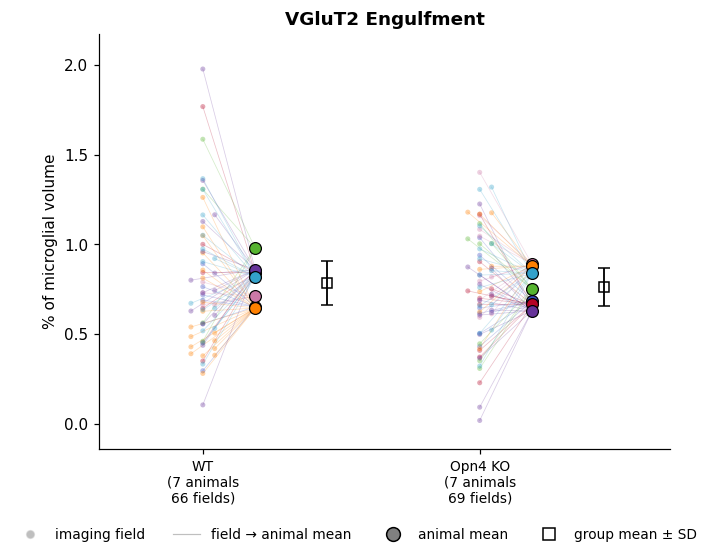

In [3]:
ep.superplot_genotype(df, "red_VGluT2_engulfment_pct"); plt.show()

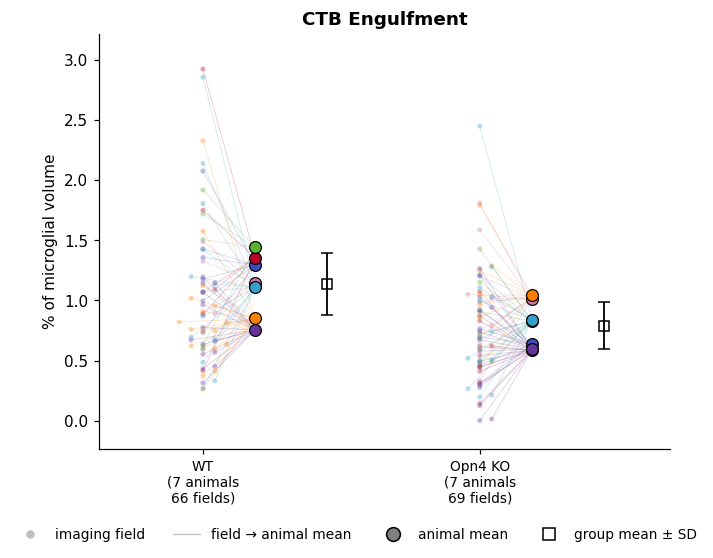

In [4]:
ep.superplot_genotype(df, "blue_CTB_engulfment_pct"); plt.show()

### All other metrics (WT vs *Opn4* KO)

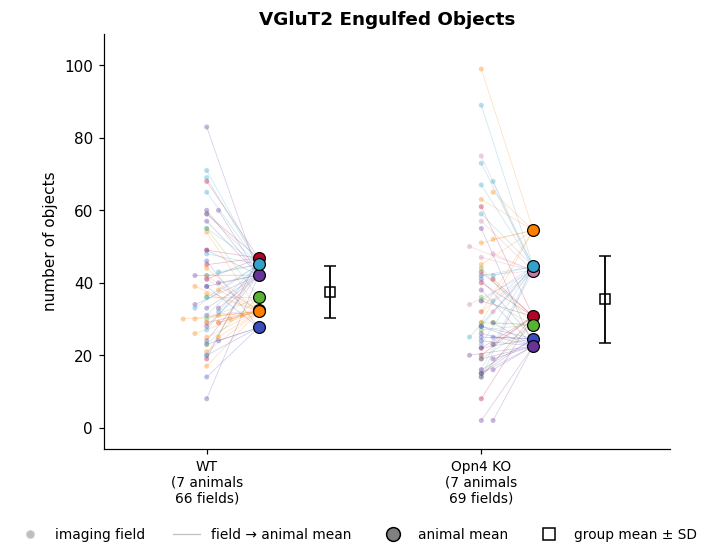

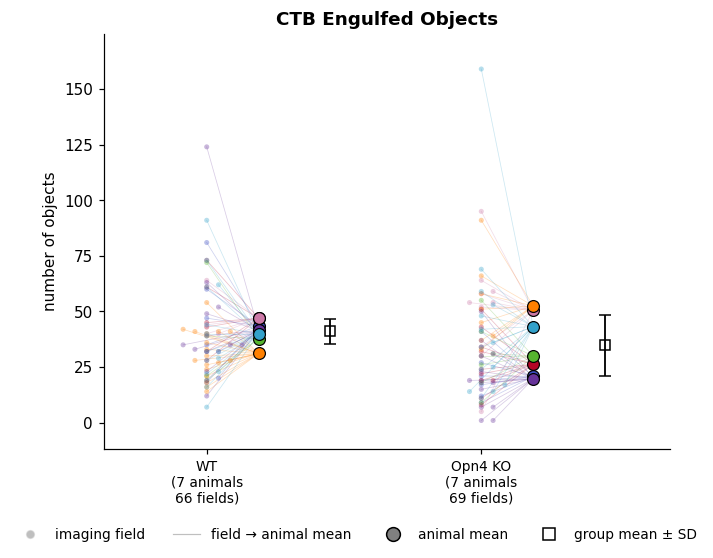

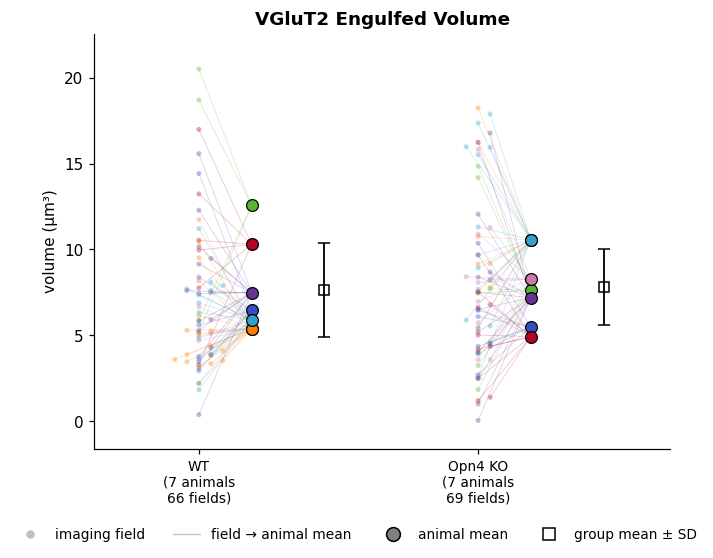

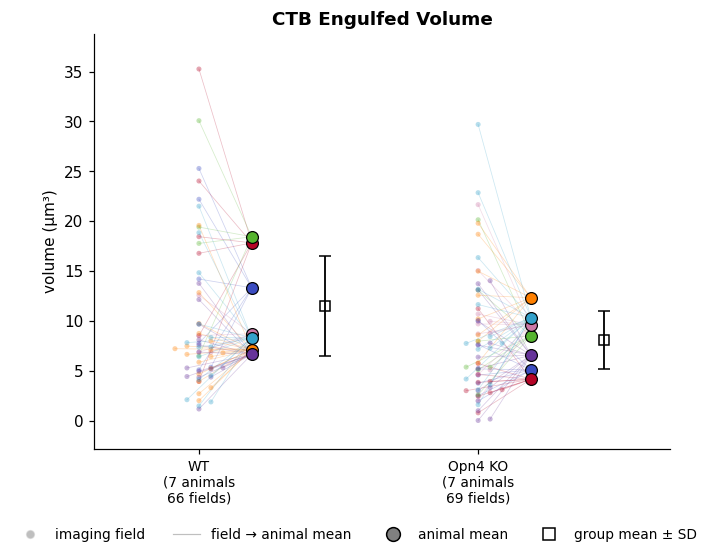

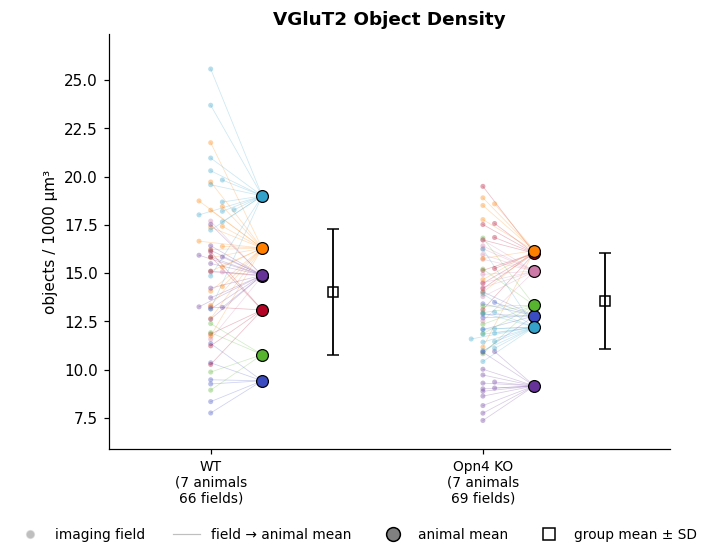

In [5]:
for m in ["red_VGluT2_engulfed_objects", "blue_CTB_engulfed_objects",
          "red_VGluT2_engulfed_volume_um3", "blue_CTB_engulfed_volume_um3",
          "red_VGluT2_density_per_1000um3"]:
    ep.superplot_genotype(df, m); plt.show()


---
# Breakdown by sex

Because of limited cohort availability, several female mice were included in the
final analysis. To make this composition transparent, the same engulfment
measures are shown below broken down by sex within each genotype.

**These plots are descriptive only.** The female subgroups are small (WT: 2
females; *Opn4* KO: a single female), so they cannot support a formal test of a
sex difference, and none is performed. The plots simply show where the male and
female animals fall relative to the pooled genotype comparison above. Animal and
field counts are printed on every column.


In [6]:
# Composition by genotype and sex
comp = (df.groupby(["genotype", "sex"])
          .agg(n_animals=("replicate", "nunique"),
               n_fields=("replicate", "size"))
          .reset_index())
comp


,genotype,sex,n_animals,n_fields
0,Opn4 KO,F,1,14
1,Opn4 KO,M,6,55
2,WT,F,2,28
3,WT,M,5,38


### VGluT2 engulfment by sex

Shown two ways: as Male | Female panels (WT vs KO within each), and as a single
four-column figure.


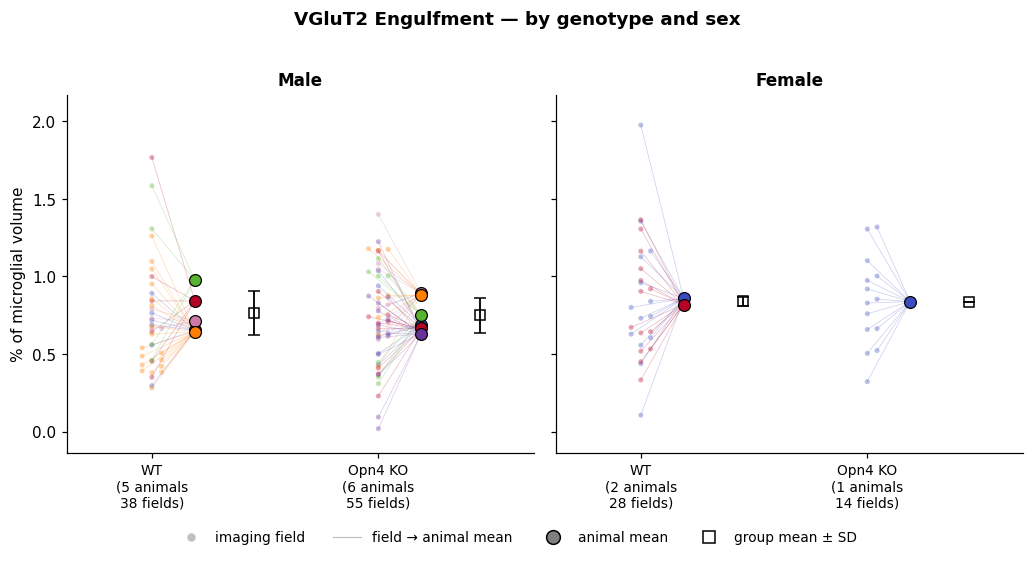

In [7]:
ep.superplot_split(df, "red_VGluT2_engulfment_pct", "separate"); plt.show()

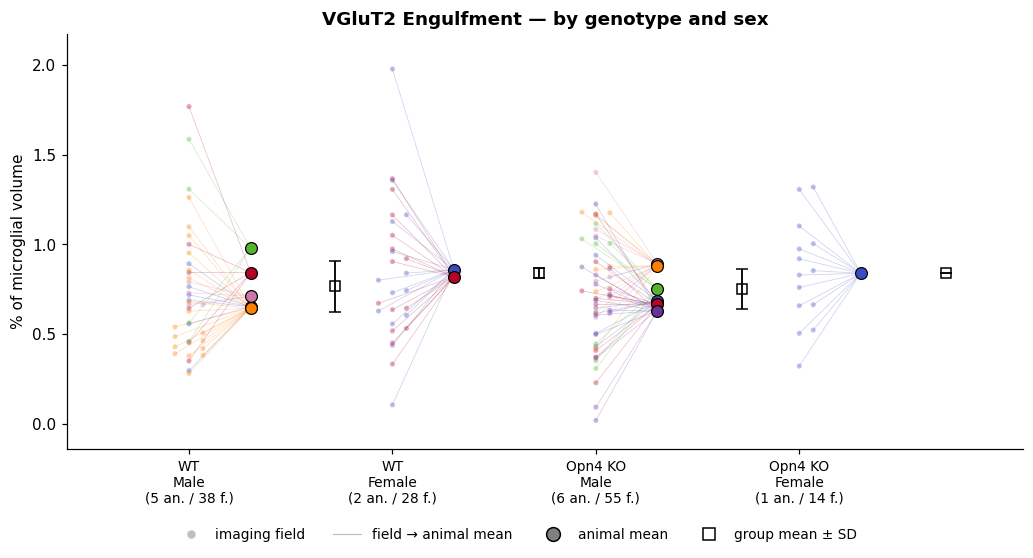

In [8]:
ep.superplot_split(df, "red_VGluT2_engulfment_pct", "four"); plt.show()

### CTB engulfment by sex

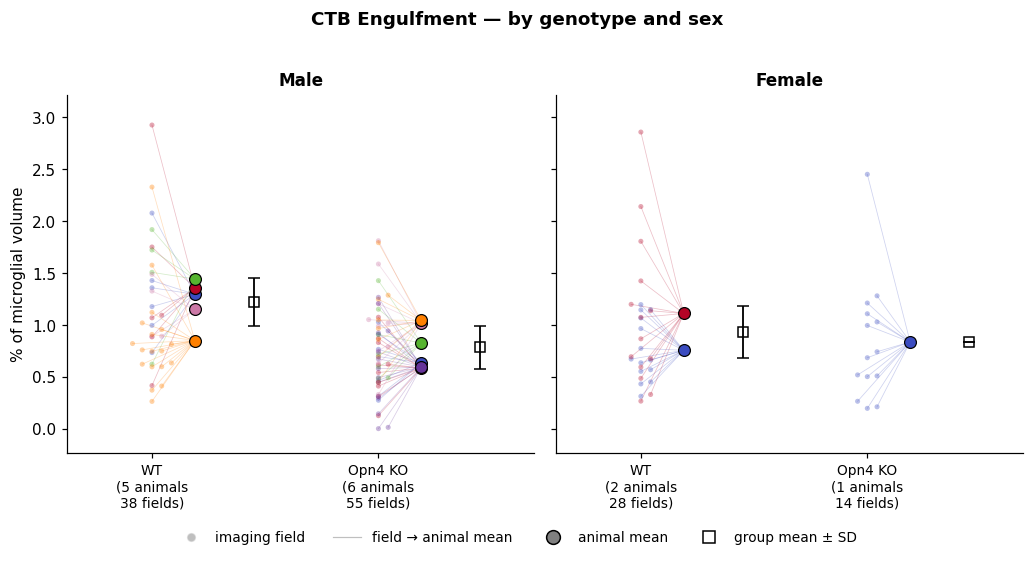

In [9]:
ep.superplot_split(df, "blue_CTB_engulfment_pct", "separate"); plt.show()

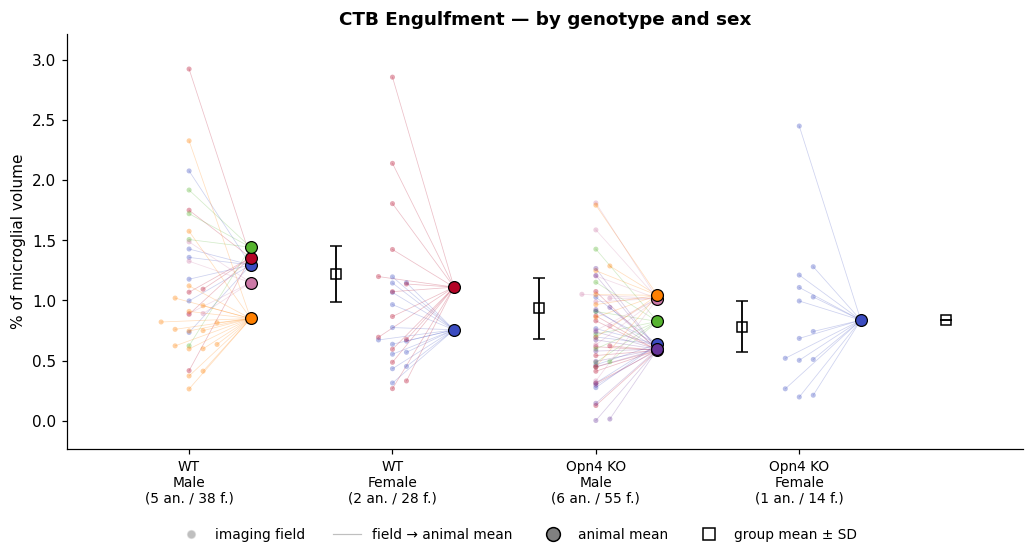

In [10]:
ep.superplot_split(df, "blue_CTB_engulfment_pct", "four"); plt.show()

### Any metric, interactively

Run the cell below to pick a metric and layout from dropdowns (requires
`ipywidgets`; otherwise a static example is shown).


In [11]:
try:
    from ipywidgets import interact, Dropdown
    interact(lambda metric, layout: (ep.superplot_split(df, metric, layout), plt.show()),
             metric=Dropdown(options=list(ep.METRIC_INFO), description="metric"),
             layout=Dropdown(options=["separate", "four"], description="layout"))
except Exception:
    print("ipywidgets not available — showing a static example.")
    ep.superplot_split(df, "red_VGluT2_engulfed_objects", "separate"); plt.show()


interactive(children=(Dropdown(description='metric', options=('red_VGluT2_engulfment_pct', 'blue_CTB_engulfmen…

---
# Export all figures

Writes 300-dpi PNG plus vector PDF and EPS for the genotype comparison and both sex
layouts, for every metric, into `figures/`.


In [12]:
for metric in ep.METRIC_INFO:
    fig = ep.superplot_genotype(df, metric, outfile=f"figures/{metric}_genotype.png"); plt.close(fig)
    fig = ep.superplot_split(df, metric, "separate", outfile=f"figures/{metric}_split_separate.png"); plt.close(fig)
    fig = ep.superplot_split(df, metric, "four", outfile=f"figures/{metric}_split_four.png"); plt.close(fig)
print("All figures exported to figures/")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


...

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


All figures exported to figures/


---
## Reproducing from raw images

1. `scripts/SimplePunctaAnalysis_v5.m`, `MODE='tune'` — tune segmentation on a
   representative field; save parameters.
2. `MODE='batch'` — process everything; writes `engulfment_results.csv` plus QC
   images, masks, MIPs, and montages.
3. `scripts/SuperPlot_FromCSV_v3.m` — the MATLAB SuperPlots (WT vs KO).

See `README.md` for the folder layout, parameters, and dependencies.
